题目描述：
已知一个四层前馈神经网络（全连接），结构如下：
输入层：6 个神经元
隐藏层1：8 个神经元，激活函数为 ReLU，带 BatchNorm1d
隐藏层2：8 个神经元，激活函数为 ReLU，带 BatchNorm1d，与隐藏层1有残差连接
隐藏层3：4 个神经元，激活函数为 GELU
输出层：4 个神经元（多分类），无激活（CrossEntropyLoss 自动加 softmax）
参数初始化（均需 requires_grad=True）：

W1 = shape [8, 6]，b1 = [8]

W2 = shape [8, 8]，b2 = [8]

W3 = shape [4, 8]，b3 = [4]

W_out = shape [4, 4]，b_out = [4]

BatchNorm1d 层参数初始化为默认
输入特征与标签（Batch）：
X = [[1.0, -1.0, 2.0, 0.5, 0.0, 1.0], [0.5, 0.0, -1.5, 1.0, 2.0, -0.5], [2.0, 1.0, 0.0, -1.0, 1.5, 0.5], [0.0, 0.0, 1.0, 1.0, -1.0, 2.0]] # shape = [4, 6]

y = [2, 0, 1, 3] # shape = [4]，分别对应四个样本的类别

正则化与优化要求：
L1正则化：损失函数中加入所有权重参数（W1、W2、W3、W_out）的L1正则项，正则系数λ1=0.01
L2正则化：损失函数中加入所有权重参数（W1、W2、W3、W_out）的L2正则项，正则系数λ2=0.01
动态学习率：如果当前 epoch 损失高于上一个 epoch，则学习率减半，否则保持不变，初始 lr=0.1
残差连接要求：
隐藏层2的输出为：H2 = ReLU(BN2(H1 @ W2^T + b2) + H1) # H1和H2 shape一致
计算要求：
前向传播
计算隐藏层1输出 H1 = ReLU(BN1(X @ W1^T + b1))
计算隐藏层2输出 H2 = ReLU(BN2(H1 @ W2^T + b2) + H1) # 残差连接
计算隐藏层3输出 H3 = GELU(H2 @ W3^T + b3)
计算输出层 Z = H3 @ W_out^T + b_out
用 nn.CrossEntropyLoss() 计算损失，并加上L1、L2正则项
反向传播
loss.backward()，获得各参数的梯度
参数更新
用当前学习率手动SGD更新一次参数（不使用优化器）
若损失未下降，学习率减半
输出结果
打印 softmax 后的输出概率
打印损失值（含正则项）
打印每个参数的梯度
打印更新后的参数值
打印每个 epoch 的学习率变化

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available else "cpu")

In [ ]:
def forward(w1, w2, w3, w_out, b1, b2, b3, b_out, x):
  z1 = x @ w1.T +b1
  bn = nn.BatchNorm1d(8)
  h1 = torch.relu(z1)
  h1_bn = bn(h1)

  z2 = h1_bn @ w2.T +b2
  bn = nn.BatchNorm1d(8)
  h2 = torch.relu(z2)
  h2_bn = bn(h2)

  z3 = h2_bn @ w3.T +b3
  h3 = nn.functional.gelu(z3)

  z_out = h3 @ w_out.T +b_out

  return z_out

epoch: 200 loss: 0.0000
the predication value is:
tensor([[0.0000e+00, 8.0626e-23, 1.0000e+00, 7.5101e-26],
        [1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.0000e+00, 9.2175e-32, 0.0000e+00],
        [1.4013e-45, 3.2156e-37, 6.6900e-11, 1.0000e+00]],
       grad_fn=<SoftmaxBackward0>)
the y_pred index is:
tensor(2)
the y_true index is:
tensor([2, 0, 1, 3])


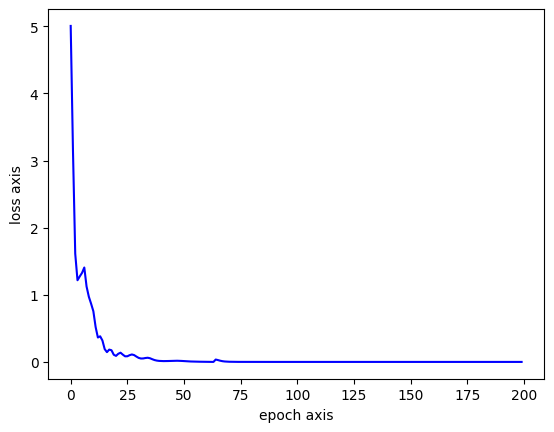

In [10]:
#初始化
w1 = torch.randn(8,6, requires_grad=True)
b1 = torch.randn(8, requires_grad=True)

w2 = torch.randn(8,8, requires_grad=True)
b2 = torch.randn(8, requires_grad=True)

w3 = torch.randn(4,8, requires_grad=True)
b3 = torch.randn(4, requires_grad=True)

w_out = torch.randn(4,4, requires_grad=True)
b_out = torch.randn(4, requires_grad=True)

x = torch.tensor([[1.0, -1.0, 2.0, 0.5, 0.0, 1.0],
          [0.5, 0.0, -1.5, 1.0, 2.0, -0.5],
          [2.0, 1.0, 0.0, -1.0, 1.5, 0.5],
          [0.0, 0.0, 1.0, 1.0, -1.0, 2.0]])

y_true_index = torch.tensor([2, 0, 1, 3])

losses = []
epochs = 200

lr = 0.1
criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):
  z_out = forward(w1, w2, w3, w_out, b1, b2, b3, b_out, x)
  y_pred = torch.softmax(z_out, dim=1)

  loss = criterion(z_out, y_true_index)
  losses.append(loss.item())

  loss.backward()

  with torch.no_grad():
    w1 -= lr * w1.grad
    w2 -= lr * w2.grad
    b1 -= lr * b1.grad
    b2 -= lr * b2.grad
    w_out -= lr * w_out.grad
    b_out -= lr * b_out.grad

with torch.no_grad():
  y_pred_index = torch.argmax(y_pred)

print(f"epoch: {epoch+1}",
   f"loss: {loss.item():.4f}")

print("the predication value is:")
print(y_pred)

print("the y_pred index is:")
print(y_pred_index)

print("the y_true index is:")
print(y_true_index)

plt.plot(range(epochs), losses, "blue")
plt.xlabel("epoch axis")
plt.ylabel("loss axis")

plt.show()